In [9]:
import os
import json
from openai import OpenAI
from google.colab import userdata

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
client = OpenAI(api_key=userdata.get('openai_IK'))

In [3]:
# Mock dataset for text embedding and vector search practice
documents = [
    # Category: Technology & AI
    {"id": 1, "category": "Tech", "text": "Artificial intelligence and machine learning are transforming modern industries."},
    {"id": 2, "category": "Tech", "text": "Python is a popular programming language for data science and automation."},
    {"id": 3, "category": "Tech", "text": "Deep neural networks require large datasets and powerful GPUs to train effectively."},

    # Category: Food & Cooking
    {"id": 4, "category": "Food", "text": "Baking homemade sourdough bread requires patience, flour, water, and wild yeast."},
    {"id": 5, "category": "Food", "text": "A classic Italian pasta carbonara uses guanciale, egg yolks, and Pecorino Romano."},
    {"id": 6, "category": "Food", "text": "The chef prepared a delicious three-course meal featuring fresh, local ingredients."},

    # Category: Fitness & Health
    {"id": 7, "category": "Fitness", "text": "Cardiovascular exercises like running and swimming improve heart health and endurance."},
    {"id": 8, "category": "Fitness", "text": "Strength training with compound lifts builds muscle mass and increases bone density."},
    {"id": 9, "category": "Fitness", "text": "Proper hydration and consistent sleep are crucial for athletic recovery."},

    # Category: Travel & Nature
    {"id": 10, "category": "Travel", "text": "Hiking through the rugged trails of the Swiss Alps offers breathtaking mountain views."},
    {"id": 11, "category": "Travel", "text": "Exploring the vibrant night markets of Tokyo is an incredible cultural experience."},
    {"id": 12, "category": "Travel", "text": "The pristine white sand beaches of the Maldives are perfect for a relaxing vacation."}
]

In [8]:
# Create an empty list to store your document embeddings
for doc in documents:
    response = client.embeddings.create(
        model="text-embedding-3-small",
        input=doc["text"]  # <-- This was the missing argument!
    )
    # Extract the embedding vector and store it in the dictionary
    doc["embedding"] = response.data[0].embedding

print(f"Successfully embedded {len(documents)} documents!")
print(f"Embedding vector size: {len(documents[0]['embedding'])}")

Successfully embedded 12 documents!
Embedding vector size: 1536


## Basic Similarity Search

In [30]:
input = "AI is transforming the world"

query = client.embeddings.create(
  model="text-embedding-3-small",
  input=input
)
response = np.array(query.data[0].embedding).reshape(1,-1)

similar_row = -1
best_score = -1

for row in documents:
  row_doc = np.array(row['embedding']).reshape(1,-1)
  score = cosine_similarity(response, row_doc)[0][0]

  if score > best_score:
    best_score = score
    similar_row = row
  print(f"Embedding similarity between '{input}' and '{row['text'][:10]}'....{row['text'][-10:]}: {round(score,2)}")

print("*"*50)
print(f"\nThe most similar document is '{similar_row['text']}'")

Embedding similarity between 'AI is transforming the world' and 'Artificial'....ndustries.: 0.6
Embedding similarity between 'AI is transforming the world' and 'Python is '....utomation.: 0.25
Embedding similarity between 'AI is transforming the world' and 'Deep neura'....fectively.: 0.26
Embedding similarity between 'AI is transforming the world' and 'Baking hom'....ild yeast.: -0.03
Embedding similarity between 'AI is transforming the world' and 'A classic '....no Romano.: 0.03
Embedding similarity between 'AI is transforming the world' and 'The chef p'....gredients.: 0.09
Embedding similarity between 'AI is transforming the world' and 'Cardiovasc'....endurance.: 0.06
Embedding similarity between 'AI is transforming the world' and 'Strength t'....e density.: 0.08
Embedding similarity between 'AI is transforming the world' and 'Proper hyd'.... recovery.: 0.1
Embedding similarity between 'AI is transforming the world' and 'Hiking thr'....ain views.: 0.12
Embedding similarity between 'A

## Metadata based Filtering

In [31]:
input = "AI is transforming the world"

query = client.embeddings.create(
  model="text-embedding-3-small",
  input=input
)
response = np.array(query.data[0].embedding).reshape(1,-1)

similar_row = -1
best_score = -1

filtered_docs = [doc for doc in documents if doc['category'] == 'Tech']

for row in filtered_docs:
  row_doc = np.array(row['embedding']).reshape(1,-1)
  score = cosine_similarity(response, row_doc)[0][0]

  if score > best_score:
    best_score = score
    similar_row = row
  print(f"Embedding similarity between '{input}' and '{row['text'][:10]}'....{row['text'][-10:]}: {round(score,2)}")

print("*"*50)
print(f"\nThe most similar document is '{similar_row['text']}'")

Embedding similarity between 'AI is transforming the world' and 'Artificial'....ndustries.: 0.6
Embedding similarity between 'AI is transforming the world' and 'Python is '....utomation.: 0.25
Embedding similarity between 'AI is transforming the world' and 'Deep neura'....fectively.: 0.26
**************************************************

The most similar document is 'Artificial intelligence and machine learning are transforming modern industries.'


## Batching vs Single Call

In [51]:
import time

batched_docs = [doc['text'] for doc in documents]

print("\nMethod 1: Batch API call...")
start = time.time()

response = client.embeddings.create(model="text-embedding-3-small", input=batched_docs)
for i, doc in enumerate(documents):
  doc['embedding'] = response.data[i].embedding
time_batch = time.time() - start
print(f"  Time: {time_batch:.2f} seconds")

print("\nMethod 2: Single API call...")
start = time.time()
for doc in documents:
  response = client.embeddings.create(model="text-embedding-3-small", input=doc['text'])
  doc['embedding'] = response.data[0].embedding
time_single = time.time() - start
print(f"  Time: {time_single:.2f} seconds")



Method 1: Batch API call...
  Time: 0.55 seconds

Method 2: Single API call...
  Time: 3.22 seconds


## Visual Representation

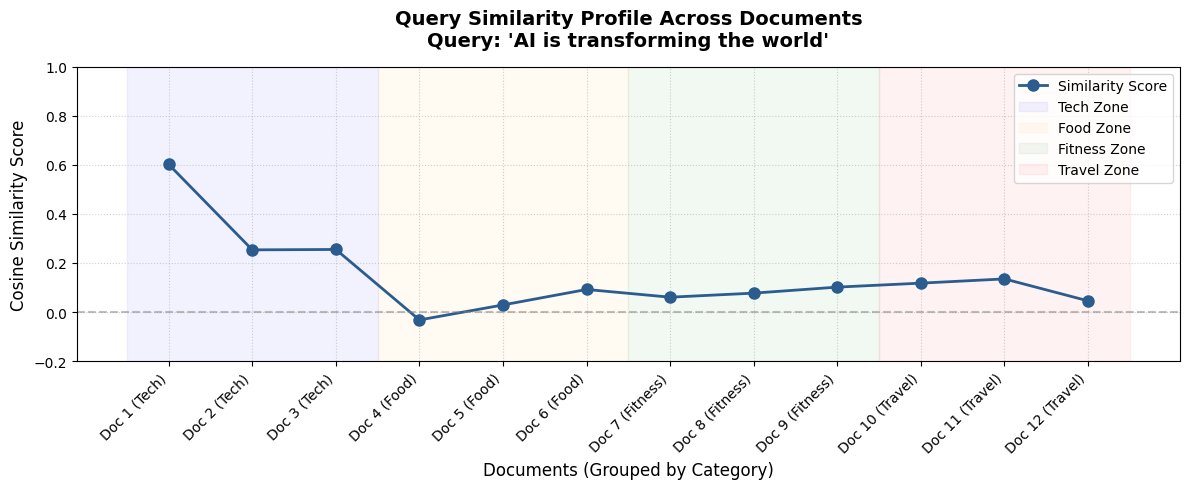

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Extract similarity scores between the query (index 12) and the 12 documents (indices 0 to 11)
query_scores = similarity_matrix[12, :12]

# Create descriptive labels for the x-axis showing Doc ID and Category
doc_labels = [f"Doc {doc['id']} ({doc['category']})" for doc in documents]

# 2. Configure and plot the line chart
plt.figure(figsize=(12, 5))
plt.plot(
    doc_labels,
    query_scores,
    marker='o',          # Add circular dots at each document point
    linestyle='-',       # Solid line connecting them
    color='#2b5c8f',     # Consistent blue theme
    linewidth=2,
    markersize=8,
    label='Similarity Score'
)

# 3. Add a baseline at 0.0 for reference
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)

# Shading background regions to visually demarcate categories
plt.axvspan(-0.5, 2.5, color='blue', alpha=0.05, label='Tech Zone')
plt.axvspan(2.5, 5.5, color='orange', alpha=0.05, label='Food Zone')
plt.axvspan(5.5, 8.5, color='green', alpha=0.05, label='Fitness Zone')
plt.axvspan(8.5, 11.5, color='red', alpha=0.05, label='Travel Zone')

# 4. Labels and styling
plt.title(f"Query Similarity Profile Across Documents\nQuery: '{query_text}'", fontsize=14, weight='bold', pad=15)
plt.xlabel("Documents (Grouped by Category)", fontsize=12)
plt.ylabel("Cosine Similarity Score", fontsize=12)
plt.ylim(-0.2, 1.0)  # Standardize range to match your histogram
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()